## Análise Exploratória

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('/content/drive/MyDrive/Dados_Csv/churn.csv')

In [3]:
dados

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           10000 non-null  int64  
 1   score_credito        10000 non-null  int64  
 2   pais                 10000 non-null  object 
 3   sexo_biologico       10000 non-null  object 
 4   idade                10000 non-null  int64  
 5   anos_de_cliente      10000 non-null  int64  
 6   saldo                10000 non-null  float64
 7   servicos_adquiridos  10000 non-null  int64  
 8   tem_cartao_credito   10000 non-null  int64  
 9   membro_ativo         10000 non-null  int64  
 10  salario_estimado     10000 non-null  float64
 11  churn                10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
# esse tipo de informação única para cada linha não é útil para uso em modelos de machine learning.
dados.drop(columns = 'id_cliente', inplace=True)

In [6]:
dados

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


### Variáveis categóricas

In [7]:
import plotly.express as px

In [8]:
px.histogram(dados, x='pais', text_auto=True, color='churn', barmode='group')

In [9]:
px.histogram(dados, x='sexo_biologico', text_auto=True, color='churn', barmode='group')

### Variáveis numéricas

In [10]:
px.box(dados, x='score_credito', color='churn')

In [11]:
px.box(dados, x='idade', color='churn')

In [12]:
px.box(dados, x='anos_de_cliente', color='churn')

In [13]:
px.box(dados, x='saldo', color='churn')

In [14]:
px.box(dados, x='servicos_adquiridos', color='churn')

## Transformação de dados

### Variáveis explicativas e variável alvo

In [15]:
x = dados.drop(columns = 'churn')
y = dados['churn']

### Transformando variáveis explicativas

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

In [17]:
colunas = x.columns

In [18]:
x

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,França,Homem,39,5,0.00,2,1,0,96270.64
9996,516,França,Homem,35,10,57369.61,1,1,1,101699.77
9997,709,França,Mulher,36,7,0.00,1,0,1,42085.58
9998,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52


In [19]:
one_hot = make_column_transformer((
    OneHotEncoder(drop='if_binary'),
    ['pais','sexo_biologico']
),
    remainder = 'passthrough',
    sparse_threshold=0)

In [20]:
x = one_hot.fit_transform(x)

In [21]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__sexo_biologico_Mulher', 'remainder__score_credito',
       'remainder__idade', 'remainder__anos_de_cliente',
       'remainder__saldo', 'remainder__servicos_adquiridos',
       'remainder__tem_cartao_credito', 'remainder__membro_ativo',
       'remainder__salario_estimado'], dtype=object)

In [22]:
pd.DataFrame(x, columns = one_hot.get_feature_names_out(colunas))

,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__sexo_biologico_Mulher,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__servicos_adquiridos,remainder__tem_cartao_credito,remainder__membro_ativo,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,1.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,0.0,0.0,1.0,1.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,0.0,0.0,1.0,1.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,1.0,0.0,1.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64
9996,0.0,0.0,1.0,0.0,516.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77
9997,0.0,0.0,1.0,1.0,709.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58
9998,1.0,0.0,0.0,0.0,772.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52


### Transformando variável alvo

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
label_encoder = LabelEncoder()

In [25]:
y = label_encoder.fit_transform(y)

In [26]:
y

array([1, 0, 1, ..., 1, 1, 0])

## Ajustando Modelos

### Divisão treino e teste

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x,y, stratify=y, random_state=5)

### Modelo de base

In [29]:
from sklearn.dummy import DummyClassifier

In [30]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.7964

### Árvore de decisão

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
arvore = DecisionTreeClassifier(random_state=5)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(random_state=5)

In [33]:
arvore.predict(x_teste)

array([0, 0, 0, ..., 0, 0, 0])

In [34]:
arvore.score(x_teste, y_teste)

0.7984

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

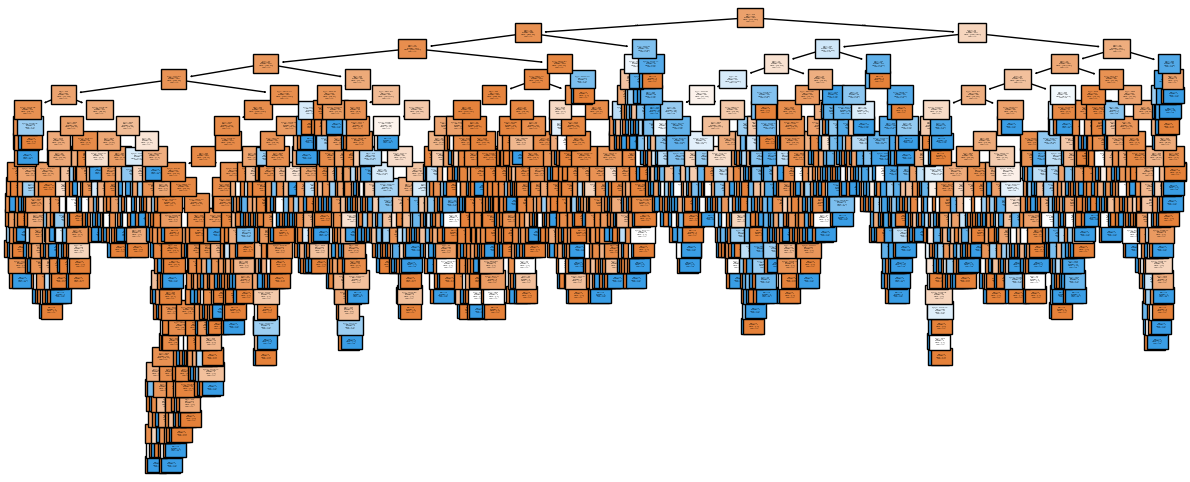

In [36]:
plt.figure(figsize=(15,6))
plot_tree(arvore, filled=True, class_names=['não','sim'], fontsize=1);

In [37]:
arvore.score(x_treino, y_treino)

1.0

In [38]:
arvore = DecisionTreeClassifier(max_depth = 4, random_state=5)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=4, random_state=5)

In [39]:
arvore.score(x_treino, y_treino)

0.8509333333333333

In [40]:
arvore.score(x_teste, y_teste)

0.8464

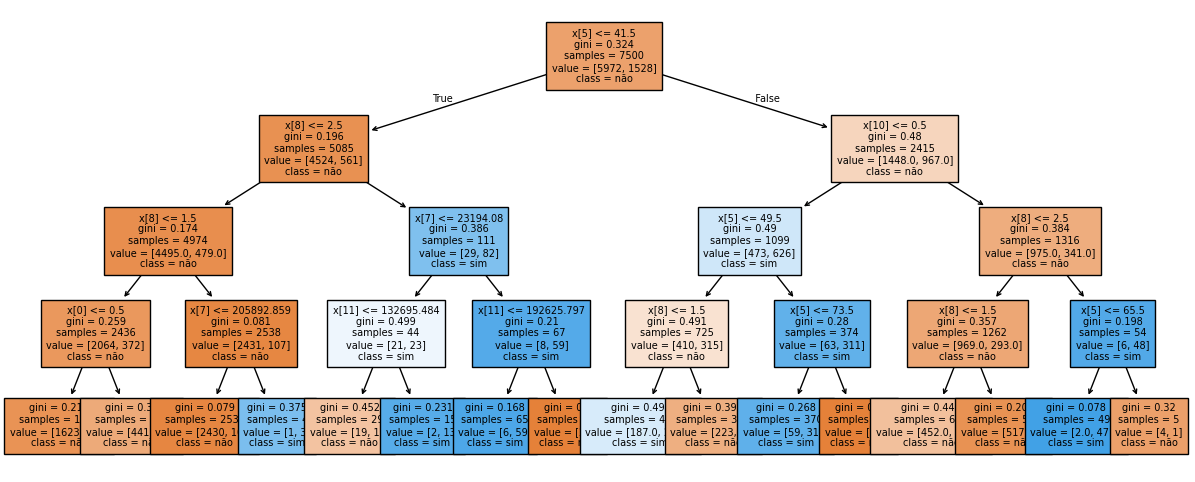

In [41]:
plt.figure(figsize=(15,6))
plot_tree(arvore, filled=True, class_names=['não','sim'], fontsize=7);

## Seleção de modelos

### Normalização de dados

In [42]:
from sklearn.preprocessing import MinMaxScaler

In [43]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

### KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn = KNeighborsClassifier()

In [46]:
knn.fit(x_treino_normalizado, y_treino)

KNeighborsClassifier()

In [47]:
x_teste_normalizado = normalizacao.transform(x_teste)

In [48]:
knn.score(x_teste_normalizado, y_teste)

0.8172

### Escolhendo e salvando o melhor modelo

In [49]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste)}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')

Acurácia Dummy: 0.7964
Acurácia Árvore: 0.8464
Acurácia KNN: 0.8172


In [50]:
import pickle

In [51]:
with open('modelo_onehotenc.pkl','wb') as f:
  pickle.dump(one_hot, f)

In [52]:
with open('modelo_arvore.pkl','wb') as f:
  pickle.dump(arvore, f)

In [54]:
novo_dado = pd.DataFrame({
    'score_credito': [850],
    'pais':['França'],
    'sexo_biologico':['Homem'],
    'idade': [27],
    'anos_de_cliente': [3],
    'saldo': [56000],
    'servicos_adquiridos': [1],
    'tem_cartao_credito': [1],
    'membro_ativo': [1],
    'salario_estimado': [85270.00]
})

In [55]:
novo_dado = pd.DataFrame(novo_dado)

In [56]:
modelo_one_hot = pd.read_pickle('/content/modelo_onehotenc.pkl')
modelo_arcore = pd.read_pickle('/content/modelo_arvore.pkl')

In [57]:
novo_dado = modelo_one_hot.transform(novo_dado)

In [58]:
modelo_arcore.predict(novo_dado)

array([0])